In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [50]:
df = pd.read_csv("/kaggle/input/datasets/visualcodepo/jeruk-balance/jeruk_balance_500.csv")
df

,diameter,berat,tebal_kulit,kadar_gula,asal_daerah,warna,musim_panen,kualitas
0,7.75,216.4,0.51,11.1,Kalimantan,oranye,kemarau,Bagus
1,7.43,237.9,0.43,10.6,Jawa Tengah,kuning,kemarau,Bagus
2,7.82,195.1,0.60,12.9,Jawa Barat,oranye,hujan,Bagus
3,8.26,184.9,0.49,13.9,Kalimantan,oranye,hujan,Bagus
4,7.38,182.2,0.42,10.6,Jawa Barat,oranye,kemarau,Bagus
...,...,...,...,...,...,...,...,...
495,6.06,106.0,0.73,7.7,Jawa Tengah,hijau,kemarau,Jelek
496,5.50,108.8,0.92,10.4,Jawa Barat,hijau,kemarau,Jelek
497,5.50,95.5,1.05,8.4,Jawa Barat,hijau,hujan,Jelek
498,7.69,221.8,0.70,13.0,Jawa Barat,oranye,hujan,Bagus


In [4]:
df.shape

(500, 8)

In [5]:
df.columns

Index(['diameter', 'berat', 'tebal_kulit', 'kadar_gula', 'asal_daerah',
       'warna', 'musim_panen', 'kualitas'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diameter     500 non-null    float64
 1   berat        500 non-null    float64
 2   tebal_kulit  500 non-null    float64
 3   kadar_gula   500 non-null    float64
 4   asal_daerah  500 non-null    object 
 5   warna        500 non-null    object 
 6   musim_panen  500 non-null    object 
 7   kualitas     500 non-null    object 
dtypes: float64(4), object(4)
memory usage: 31.4+ KB


In [8]:
df.describe()

,diameter,berat,tebal_kulit,kadar_gula
count,500.000000,500.000000,500.000000,500.000000
mean,6.514780,150.670600,0.730460,10.020200
std,0.955277,44.637103,0.252194,1.882291
min,3.990000,74.400000,0.270000,5.800000
25%,5.747500,106.000000,0.540000,8.600000
50%,6.540000,151.600000,0.690000,10.100000
75%,7.290000,188.050000,0.882500,11.500000
max,8.730000,277.100000,1.620000,14.600000


In [10]:
df["asal_daerah"].value_counts()

asal_daerah
Jawa Tengah    194
Kalimantan     163
Jawa Barat     143
Name: count, dtype: int64

In [11]:
df["warna"].value_counts()

warna
hijau     255
kuning    148
oranye     97
Name: count, dtype: int64

In [12]:
df["musim_panen"].value_counts()

musim_panen
kemarau    251
hujan      249
Name: count, dtype: int64

In [13]:
df["kualitas"].value_counts()

kualitas
Bagus     168
Sedang    166
Jelek     166
Name: count, dtype: int64

In [14]:
df.head()

,diameter,berat,tebal_kulit,kadar_gula,asal_daerah,warna,musim_panen,kualitas
0,7.75,216.4,0.51,11.1,Kalimantan,oranye,kemarau,Bagus
1,7.43,237.9,0.43,10.6,Jawa Tengah,kuning,kemarau,Bagus
2,7.82,195.1,0.60,12.9,Jawa Barat,oranye,hujan,Bagus
3,8.26,184.9,0.49,13.9,Kalimantan,oranye,hujan,Bagus
4,7.38,182.2,0.42,10.6,Jawa Barat,oranye,kemarau,Bagus


In [15]:
df.tail()

,diameter,berat,tebal_kulit,kadar_gula,asal_daerah,warna,musim_panen,kualitas
495,6.06,106.0,0.73,7.7,Jawa Tengah,hijau,kemarau,Jelek
496,5.50,108.8,0.92,10.4,Jawa Barat,hijau,kemarau,Jelek
497,5.50,95.5,1.05,8.4,Jawa Barat,hijau,hujan,Jelek
498,7.69,221.8,0.70,13.0,Jawa Barat,oranye,hujan,Bagus
499,7.57,200.5,0.46,13.6,Kalimantan,oranye,hujan,Bagus


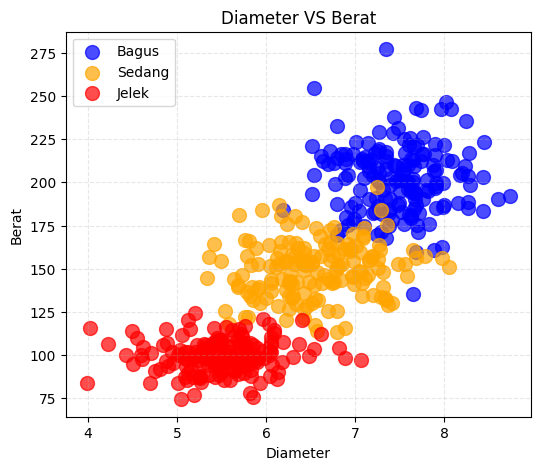

In [65]:
import matplotlib.pyplot as plt

bagus = df[df["kualitas"]=="Bagus"]
sedang = df[df["kualitas"]=="Sedang"]
jelek = df[df["kualitas"]=="Jelek"]

plt.figure(figsize=(6,5))

plt.scatter(bagus["diameter"], bagus["berat"], s=100, alpha=0.7, color="blue", label="Bagus")
plt.scatter(sedang["diameter"], sedang["berat"], s=100, alpha=0.7, color="orange", label="Sedang")
plt.scatter(jelek["diameter"], jelek["berat"], s=100, alpha=0.7, color="red", label="Jelek")

plt.xlabel("Diameter")
plt.ylabel("Berat")
plt.title("Diameter VS Berat")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

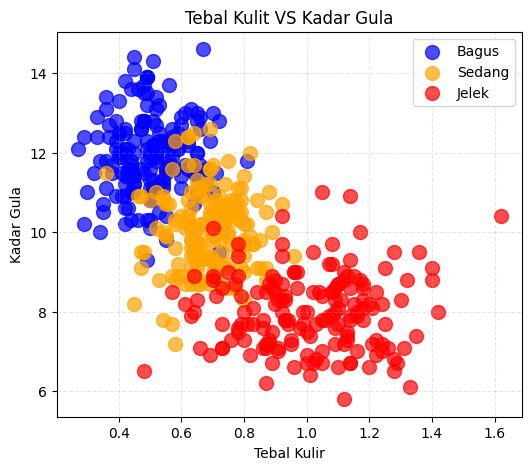

In [66]:
import matplotlib.pyplot as plt

bagus = df[df["kualitas"]=="Bagus"]
sedang = df[df["kualitas"]=="Sedang"]
jelek = df[df["kualitas"]=="Jelek"]

plt.figure(figsize=(6,5))

plt.scatter(bagus["tebal_kulit"], bagus["kadar_gula"], s=100, alpha=0.7, color="blue", label="Bagus")
plt.scatter(sedang["tebal_kulit"], sedang["kadar_gula"], s=100, alpha=0.7, color="orange", label="Sedang")
plt.scatter(jelek["tebal_kulit"], jelek["kadar_gula"], s=100, alpha=0.7, color="red", label="Jelek")

plt.xlabel("Tebal Kulir")
plt.ylabel("Kadar Gula")
plt.title("Tebal Kulit VS Kadar Gula")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

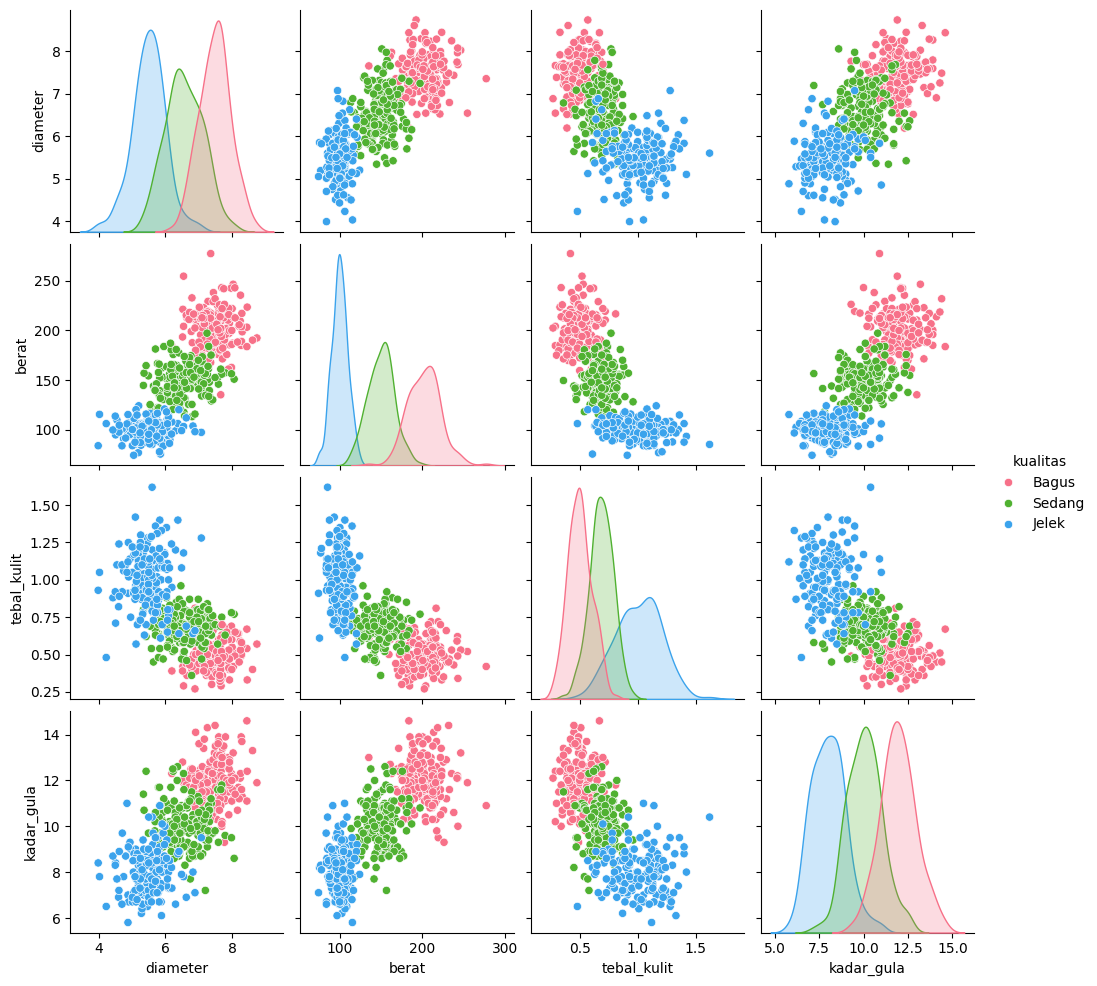

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="kualitas", palette="husl", vars=['diameter', 'berat', 'tebal_kulit', 'kadar_gula'])
plt.show()

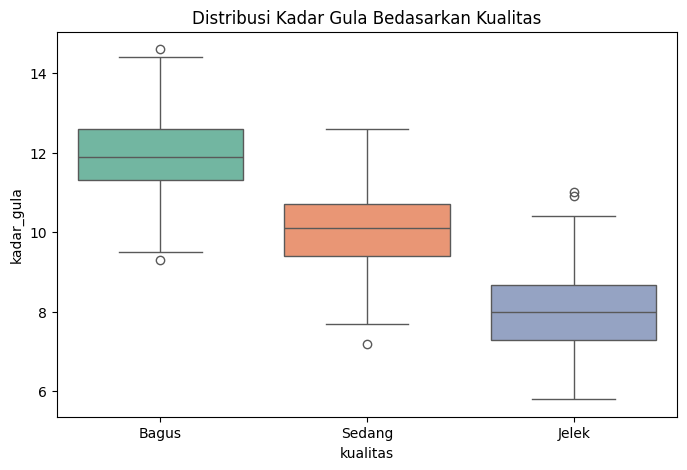

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x="kualitas", y="kadar_gula", palette="Set2", hue="kualitas", order=["Bagus", "Sedang", "Jelek"], legend=False, ax=ax)
ax.set_title("Distribusi Kadar Gula Bedasarkan Kualitas")
plt.show()

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#  diameter	berat	tebal_kulit	kadar_gula	asal_daerah	warna	musim_panen	kualitas

X=df[["diameter", "berat", "tebal_kulit", "kadar_gula", "asal_daerah", "warna", "musim_panen"]]
y=df[["kualitas"]].values.ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns =[ "diameter", "berat", "tebal_kulit", "kadar_gula"]
categorical_columns = ["asal_daerah", "musim_panen"]
ordinal_columns = ["warna"]

warna_order = ["hijau", "kuning", "oranye"]
ordinal_order = [warna_order]

preprocessing = ColumnTransformer(
    transformers = [
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", LogisticRegression()),
    ]
)

model.fit(X_train, y_train) 
#BELAJAR SANA
y_pred = model.predict(X_test)

print("Accuracy Bos :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

Accuracy Bos : 0.99

Classification Report :
               precision    recall  f1-score   support

       Bagus       1.00      1.00      1.00        35
       Jelek       1.00      0.98      0.99        41
      Sedang       0.96      1.00      0.98        24

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100


Confusion Matrix : 
 [[35  0  0]
 [ 0 40  1]
 [ 0  0 24]]


In [94]:
data_baru =pd.DataFrame([[7.89, 100, 0.35, 10, "Jawa Tengah", "hijau", "hujan",]],columns=["diameter", "berat", "tebal_kulit", "kadar_gula", "asal_daerah", "warna", "musim_panen"])

prediksi = model.predict(data_baru) [0]
presentase = max(model.predict_proba(data_baru) [0])
#LUPA DIPRINT
print(f"Model berhasil meprediksi {prediksi} dengan tingkat keyakinan {presentase*100:.2f}%")

Model berhasil meprediksi Sedang dengan tingkat keyakinan 98.62%


In [97]:
import joblib

joblib.dump(model, "model_klasifikasi_jeruk.joblib")

['model_klasifikasi_jeruk.joblib']

['model_klasifikasi_jeruk.joblib']